Hexagonal Architecture (also known as the Ports and Adapters Architecture, 
introduced by Alistair Cockburn) takes layered architecture a step further.

While classic Repository-Service-Controller (RSC) arranges code in 
top-to-bottom layers where the business logic depends directly on 
the database layer, Hexagonal Architecture places the Domain/Business Logic 
at the absolute center, completely isolated from all external tech dependencies 
(databases, HTTP frameworks, messaging queues, or 3rd-party APIs).

Core Concept: Inside vs. Outside

Instead of top/middle/bottom layers, Hexagonal Architecture thinks 
in terms of Inside (Domain) vs. Outside (Infrastructure).

                  ┌──────────────────────────────────────────────┐
                  │              OUTSIDE (INFRASTRUCTURE)        │
                  │                                              │
                  │   ┌──────────────┐       ┌──────────────┐    │
                  │   │  REST API    │       │  CLI Tool    │    │
                  │   └──────┬───────┘       └──────┬───────┘    │
                  │          │                      │            │
                  │          ▼                      ▼            │
                  │      ┌──────────────────────────────┐        │
                  │      │  PRIMARY / DRIVING PORTS     │        │
                  │      └──────────────┬───────────────┘        │
                  │                     │                        │
                  │                     ▼                        │
                  │  ┌───────────────────────────────────────┐   │
                  │  │               INSIDE                  │   │
                  │  │                                       │   │
                  │  │       CORE DOMAIN & BUSINESS LOGIC    │   │
                  │  │    (Entities, Use Cases, Value Objs)  │   │
                  │  │                                       │   │
                  │  └──────────────────┬────────────────────┘   │
                  │                     │                        │
                  │                     ▼                        │
                  │      ┌──────────────────────────────┐        │
                  │      │ SECONDARY / DRIVEN PORTS     │        │
                  │      └──────────────┬───────────────┘        │
                  │                     │                        │
                  │          ┌──────────┴──────────┐             │
                  │          ▼                     ▼             │
                  │   ┌──────────────┐      ┌──────────────┐     │
                  │   │ PostgreSQL   │      │ Stripe API   │     │
                  │   └──────────────┘      └──────────────┘     │
                  └──────────────────────────────────────────────┘
The core principle is the Dependency Inversion Principle: The core domain defines 
interface contracts (Ports), and the outside world supplies concrete 
implementations (Adapters). The core domain never imports or knows about any 
framework, ORM, HTTP driver, or API SDK.

Key Components
1. Core Domain (Inside)

    Contains pure business logic, domain entities, and use-case orchestrators.
    Written in pure programming language code with zero third-party 
    framework dependencies.
2. Ports (Inside Boundary)

    Primary (Driving) Ports: Interfaces exposed by the application 
         defining what actions can be performed on it (e.g., OrderUseCase interface).
    Secondary (Driven) Ports: Interfaces defined by the domain 
         specifying what external capabilities it needs (e.g., OrderRepositoryPort or 
    PaymentGatewayPort).

3. Adapters (Outside)

    Primary (Driving) Adapters: Trigger execution in the core domain 
        by calling Primary Ports (e.g., a FastAPI Controller,
        a Kafka Consumer, or a CLI Command).

    Secondary (Driven) Adapters: Implement Secondary Ports to connect 
        the core domain to real infrastructure (e.g., a PostgresOrderRepository 
        using SQLAlchemy or a StripePaymentAdapter).

Hexagonal Architecture in Action (Python Example)
Here is a complete example of a user payment checkout flow using pure Hexagonal Architecture.




![Screenshot From 2026-09-04 18-41-30.png](<attachment:Screenshot From 2026-09-04 18-41-30.png>)
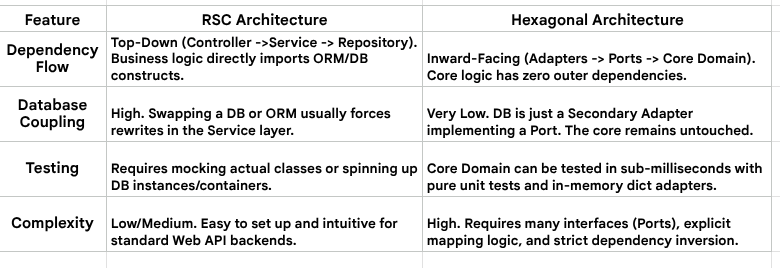

When Should You Use Hexagonal Architecture?
Use Hexagonal Architecture when:

You are building a complex domain with rich business rules expected to last for years.

You plan to support multiple drivers (e.g., triggering the same logic via REST API, gRPC, CLI scripts, or Event Bus consumers).

You want to defer infrastructure decisions (e.g., start with SQLite/JSON files for development, plug in Postgres later without changing business code).

Avoid it when:

You are building a standard CRUD app with minimal business logic. The extra layers of Ports and Adapters will feel like tedious boilerplate.